# Representação Semântica de Interações Multimodais em Robótica
### SISTEMA HÍBRIDO DE CONTROLE ROBÓTICO MULTIAGENTE

**Integração:** Neo4j (Cypher) + RDF/OWL + LLM Conversacional

---

## Arquitetura do Sistema

1. **Agente Conversacional NLU** - LLM Groq para interpretação de linguagem natural
2. **Seleção de Robôs** - Baseada em capacidades (Neo4j + RDF)
3. **Planejamento Híbrido** - Regras + Raciocínio Semântico
4. **Geração de Narrativa** - Tradução de planos simbólicos para linguagem natural

---

**Autor:** Ervin Alain Bolivar Huayhua  
**Data:** 04 de Oct de 2025  
**Disciplina:** MO656 - Introdução à Web Semântica  
**Professor:** Julio Cesar dos Reis




**SISTEMA HÍBRIDO DE CONTROLE ROBÓTICO MULTIAGENTE**

**Integração:** Neo4j (Cypher) + RDF/OWL + LLM Conversacional

---

**Pipeline do Sistema**

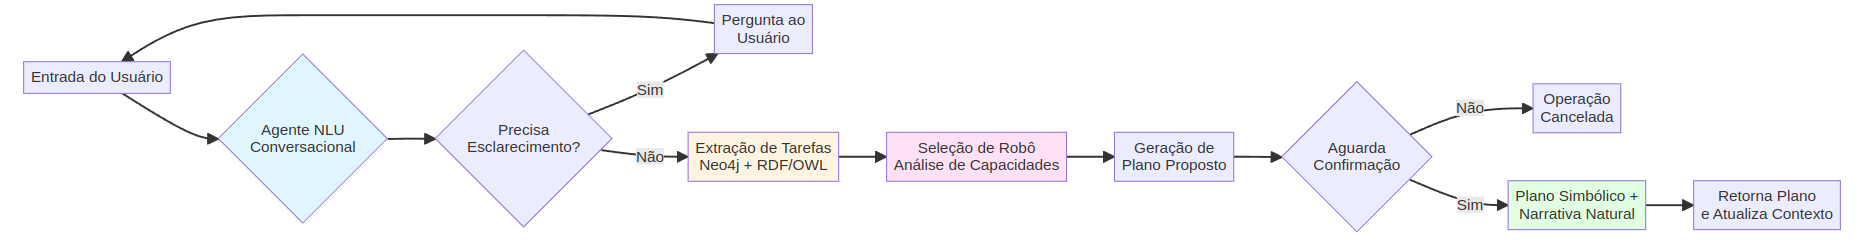

In [94]:
# ============================================
# Paso 0. Dependencias
# ============================================
# Instalar (si aún no lo tienes en tu env)
# !pip install neo4j rdflib langchain langchain-groq

from neo4j import GraphDatabase
from rdflib import Graph
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
import json
from difflib import get_close_matches
import os
from dotenv import load_dotenv

In [95]:
# ============================================
# Configuración de APIs
# ============================================
load_dotenv()
NEO4J_URI = os.getenv('NEO4J_URI')
NEO4J_USERNAME = os.getenv('NEO4J_USERNAME')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
GROQ_API_KEY = os.getenv('GROQ_TOKEN')

In [96]:
# Cores ANSI
class Cores:
    AZUL = '\033[94m'
    VERDE = '\033[92m'
    AMARELO = '\033[93m'
    CIANO = '\033[96m'
    MAGENTA = '\033[95m'
    RESET = '\033[0m'
    NEGRITO = '\033[1m'
    VERMELHO = '\033[91m'


In [97]:
# ============================================
# Paso A. Cypher Retriever (Neo4j)
# ============================================
# Configuración de conexión a Neo4j
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

def init_graph():
    with driver.session() as session:
        # Limpieza total
        session.run("MATCH (n) DETACH DELETE n")
        
        # Crear todo con CREATE en lugar de MERGE
        create = """
        //  Salas
        CREATE (s1:Sala {name:"Sala1"})
        CREATE (s2:Sala {name:"Sala2"})
        CREATE (s3:Sala {name:"Sala3"})
        
        //  Objetos
        CREATE (cup:Cup {id:"cup1", status:"on_table"})
        CREATE (light:Light {id:"light1", status:"off"})
        CREATE (bottle:Bottle {id:"bottle1", status:"on_table"})
        CREATE (apple:Apple {id:"apple1", status:"on_table"})
        CREATE (carrot:Carrot {id:"carrot1", status:"in_fridge"})
        
        //  Robots
        CREATE (rf:RobotManipulador {id:"RobotFijo", battery:100, status:"idle", canMove:false, canSpeak:false, hasArms:true})
        CREATE (rm:RobotMovil {id:"RobotMovil", battery:85, status:"idle", canMove:true, canSpeak:true, hasArms:false})
        CREATE (rh:RobotHumanoide {id:"RobotHumanoide", battery:70, status:"active", canMove:true, canSpeak:true, hasArms:true})
        
        //  Humano
        CREATE (h:Humano {id:"Ervin", canMove:false, canSpeak:true})
        
        // Relaciones de ubicación para OBJETOS
        CREATE (cup)-[:LOCATED_IN]->(s2)
        CREATE (light)-[:LOCATED_IN]->(s1)
        CREATE (bottle)-[:LOCATED_IN]->(s3)
        CREATE (apple)-[:LOCATED_IN]->(s2)
        CREATE (carrot)-[:LOCATED_IN]->(s3)
        
        // ubicacion de AGENTES (robots y humano)
        CREATE (rf)-[:LOCATED_IN]->(s1)
        CREATE (rm)-[:LOCATED_IN]->(s2)
        CREATE (rh)-[:LOCATED_IN]->(s3)
        CREATE (h)-[:LOCATED_IN]->(s1)
        
        // Conexiones entre salas
        CREATE (s1)-[:CONNECTED_TO]->(s2)
        CREATE (s2)-[:CONNECTED_TO]->(s1)
        CREATE (s1)-[:CONNECTED_TO]->(s3)
        CREATE (s3)-[:CONNECTED_TO]->(s1)
        CREATE (s2)-[:CONNECTED_TO]->(s3)
        CREATE (s3)-[:CONNECTED_TO]->(s2)
        """
        session.run(create)
        
        result = session.run("""
            MATCH (n) 
            RETURN labels(n)[0] AS tipo, count(n) AS cantidad 
            ORDER BY tipo
        """)
        
        print("═" * 50)
        print("   Grafo Neo4j inicializado com sucesso!")
        print("═" * 50)
        for record in result:
            print(f"  {record['tipo']:20s}: {record['cantidad']}")
        
        # Verificar relaciones
        rel_count = session.run("MATCH ()-[r]->() RETURN count(r) AS total").single()
        print(f"\n  Total de relações: {rel_count['total']}")
        print("═" * 50)
        print()

def get_objects_by_room(room_name):
    query = """
    MATCH (o)-[:LOCATED_IN]->(s:Sala {name:$room})
    RETURN o.id AS id, labels(o)[0] AS type, s.name AS room
    """
    with driver.session() as session:
        result = session.run(query, room=room_name)
        return [dict(record) for record in result]

def get_object_location(obj_id):
    query = """
    MATCH (o {id:$id})-[:LOCATED_IN]->(s:Sala)
    RETURN o.id AS id, labels(o)[0] AS type, s.name AS room
    """
    with driver.session() as session:
        result = session.run(query, id=obj_id)
        return [dict(record) for record in result]

def get_path_to_object(robot_id, object_id):
    query = """
    MATCH (r {id:$rid})-[:LOCATED_IN]->(s0:Sala),
          (o {id:$oid})-[:LOCATED_IN]->(s1:Sala),
          path = shortestPath((s0)-[:CONNECTED_TO*..5]->(s1))
    RETURN [n IN nodes(path) | n.name] AS rooms, o.id AS object, labels(o)[0] AS type
    """
    with driver.session() as session:
        record = session.run(query, rid=robot_id, oid=object_id).single()
        return dict(record) if record else None

def get_available_robots():
    query = """
    MATCH (r)-[:LOCATED_IN]->(s:Sala)
    WHERE r.canMove = true OR r.hasArms = true
    RETURN r.id AS id, labels(r)[0] AS type, r.canMove AS canMove, 
           r.canSpeak AS canSpeak, r.hasArms AS hasArms, 
           r.battery AS battery, s.name AS location
    """
    with driver.session() as session:
        result = session.run(query)
        return [dict(record) for record in result]

In [98]:
init_graph()

══════════════════════════════════════════════════
   Grafo Neo4j inicializado com sucesso!
══════════════════════════════════════════════════
  Apple               : 1
  Bottle              : 1
  Carrot              : 1
  Cup                 : 1
  Humano              : 1
  Light               : 1
  RobotHumanoide      : 1
  RobotManipulador    : 1
  RobotMovil          : 1
  Sala                : 3

  Total de relações: 15
══════════════════════════════════════════════════



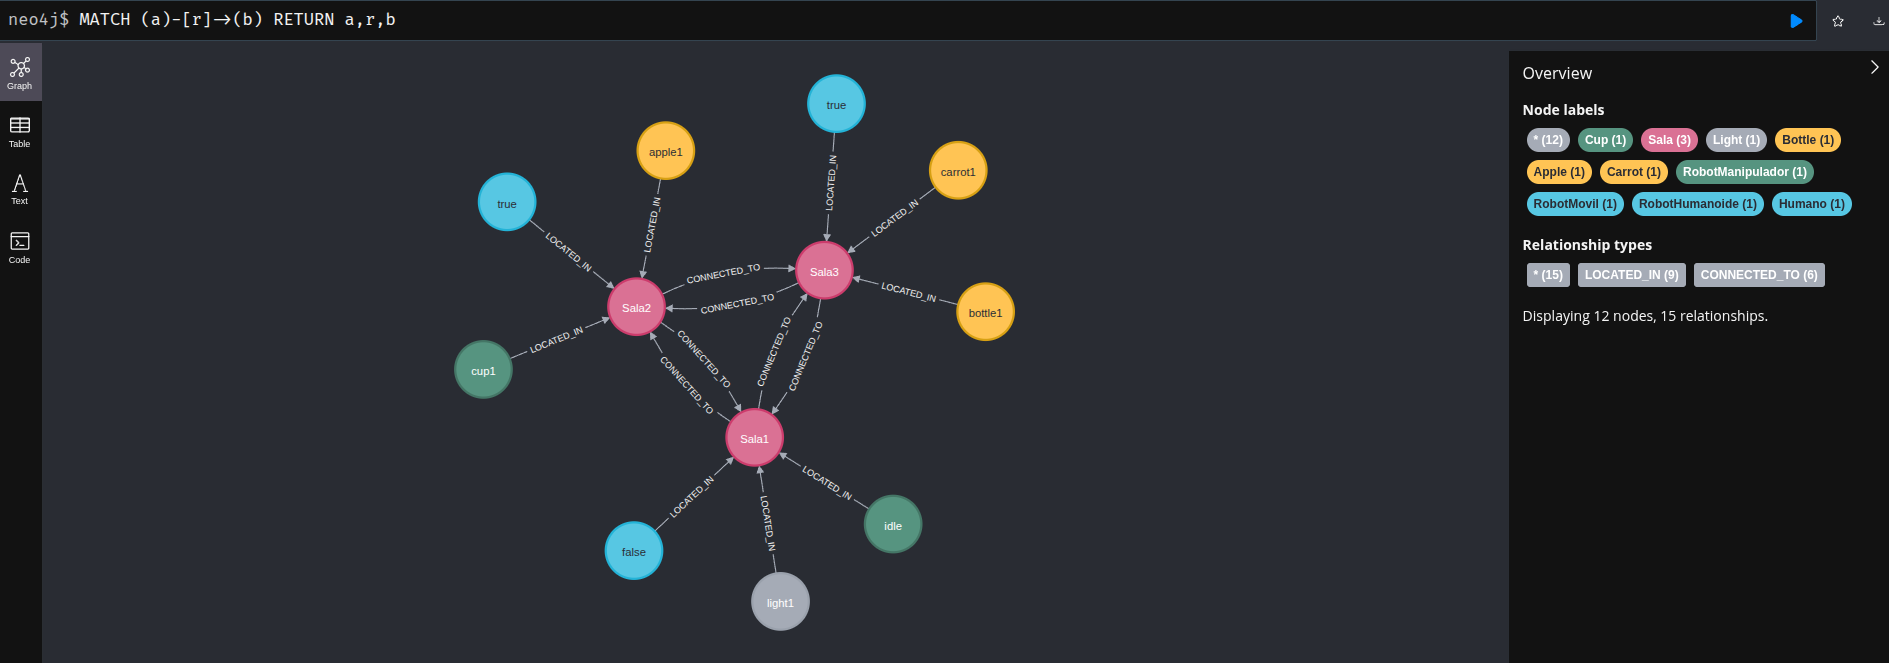

In [99]:

get_available_robots()

[{'id': 'RobotFijo',
  'type': 'RobotManipulador',
  'canMove': False,
  'canSpeak': False,
  'hasArms': True,
  'battery': 100,
  'location': 'Sala1'},
 {'id': 'RobotMovil',
  'type': 'RobotMovil',
  'canMove': True,
  'canSpeak': True,
  'hasArms': False,
  'battery': 85,
  'location': 'Sala2'},
 {'id': 'RobotHumanoide',
  'type': 'RobotHumanoide',
  'canMove': True,
  'canSpeak': True,
  'hasArms': True,
  'battery': 70,
  'location': 'Sala3'}]

In [100]:
# ============================================
# Paso B. SPARQL Retriever (RDFLib)
# ============================================

# Crear archivo de ontología simplificado
with open("actions.rdf", "w") as f:
    f.write("""
<rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
         xmlns:rdfs="http://www.w3.org/2000/01/rdf-schema#"
         xmlns:owl="http://www.w3.org/2002/07/owl#"
         xmlns:ex="http://example.org/">
         
  <!-- ============================================ -->
  <!-- CLASSES DE OBJETOS -->
  <!-- ============================================ -->
  <rdf:Description rdf:about="http://example.org/Food">
    <rdf:type rdf:resource="http://www.w3.org/2002/07/owl#Class"/>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Utensil">
    <rdf:type rdf:resource="http://www.w3.org/2002/07/owl#Class"/>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Container">
    <rdf:type rdf:resource="http://www.w3.org/2002/07/owl#Class"/>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Electronic">
    <rdf:type rdf:resource="http://www.w3.org/2002/07/owl#Class"/>
  </rdf:Description>
  
  <!-- ============================================ -->
  <!-- CLASSE ÚNICA DE AGENTE -->
  <!-- ============================================ -->
  <rdf:Description rdf:about="http://example.org/Robot">
    <rdf:type rdf:resource="http://www.w3.org/2002/07/owl#Class"/>
    <rdfs:comment>Clase genérica para todos los robots. Las capacidades individuales se almacenan en Neo4j.</rdfs:comment>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Humano">
    <rdf:type rdf:resource="http://www.w3.org/2002/07/owl#Class"/>
  </rdf:Description>
  
  <!-- ============================================ -->
  <!-- INSTÂNCIAS DE OBJETOS -->
  <!-- ============================================ -->
  <rdf:Description rdf:about="http://example.org/Apple">
    <rdf:type rdf:resource="http://example.org/Food"/>
    <ex:isPortable rdf:datatype="http://www.w3.org/2001/XMLSchema#boolean">true</ex:isPortable>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Carrot">
    <rdf:type rdf:resource="http://example.org/Food"/>
    <ex:isPortable rdf:datatype="http://www.w3.org/2001/XMLSchema#boolean">true</ex:isPortable>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Cup">
    <rdf:type rdf:resource="http://example.org/Utensil"/>
    <ex:isPortable rdf:datatype="http://www.w3.org/2001/XMLSchema#boolean">true</ex:isPortable>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Bottle">
    <rdf:type rdf:resource="http://example.org/Container"/>
    <ex:isPortable rdf:datatype="http://www.w3.org/2001/XMLSchema#boolean">true</ex:isPortable>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Light">
    <rdf:type rdf:resource="http://example.org/Electronic"/>
    <ex:isPortable rdf:datatype="http://www.w3.org/2001/XMLSchema#boolean">false</ex:isPortable>
  </rdf:Description>
  
  <!-- ============================================ -->
  <!-- AÇÕES E RESTRIÇÕES -->
  <!-- ============================================ -->
  <rdf:Description rdf:about="http://example.org/Action">
    <rdf:type rdf:resource="http://www.w3.org/2002/07/owl#Class"/>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/PickUp">
    <rdf:type rdf:resource="http://example.org/Action"/>
    <ex:appliesTo rdf:resource="http://example.org/Food"/>
    <ex:appliesTo rdf:resource="http://example.org/Utensil"/>
    <ex:appliesTo rdf:resource="http://example.org/Container"/>
    <ex:requiresCapability>hasArms</ex:requiresCapability>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Deliver">
    <rdf:type rdf:resource="http://example.org/Action"/>
    <ex:appliesTo rdf:resource="http://example.org/Food"/>
    <ex:appliesTo rdf:resource="http://example.org/Utensil"/>
    <ex:appliesTo rdf:resource="http://example.org/Container"/>
    <ex:requiresCapability>canMove</ex:requiresCapability>
    <ex:requiresCapability>hasArms</ex:requiresCapability>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Navigate">
    <rdf:type rdf:resource="http://example.org/Action"/>
    <ex:requiresCapability>canMove</ex:requiresCapability>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Speak">
    <rdf:type rdf:resource="http://example.org/Action"/>
    <ex:requiresCapability>canSpeak</ex:requiresCapability>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Open">
    <rdf:type rdf:resource="http://example.org/Action"/>
    <ex:appliesTo rdf:resource="http://example.org/Container"/>
    <ex:appliesTo rdf:resource="http://example.org/Electronic"/>
    <ex:requiresCapability>hasArms</ex:requiresCapability>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/TurnOn">
    <rdf:type rdf:resource="http://example.org/Action"/>
    <ex:appliesTo rdf:resource="http://example.org/Electronic"/>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/TurnOff">
    <rdf:type rdf:resource="http://example.org/Action"/>
    <ex:appliesTo rdf:resource="http://example.org/Electronic"/>
  </rdf:Description>
  
  <rdf:Description rdf:about="http://example.org/Request">
    <rdf:type rdf:resource="http://example.org/Action"/>
    <ex:performedBy rdf:resource="http://example.org/Humano"/>
    <ex:requiresCapability>canSpeak</ex:requiresCapability>
  </rdf:Description>
  
</rdf:RDF>
""")

def init_sparql_graph():
    g = Graph()
    g.parse("actions.rdf")
    print("═" * 50)
    print("   Ontologia RDF carregada com sucesso!")
    print("═" * 50)
    print(f"  Total de triplas: {len(g)}")
    print("═" * 50)
    print()
    return g

def get_actions_for_objects(g):
    """Retorna mapeamento de objetos para ações permitidas"""
    query = """
    PREFIX ex:  <http://example.org/>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    SELECT ?obj ?action
    WHERE {
      ?obj  rdf:type   ?class .
      ?action ex:appliesTo ?class .
    }
    """
    results = g.query(query)
    out = {}
    for obj, act in results:
        obj_name = str(obj).split("/")[-1]
        act_name = str(act).split("/")[-1]
        out.setdefault(obj_name, []).append(act_name)
    return out

def get_action_requirements(g, action_name):
    """Retorna capacidades requeridas para una acción específica"""
    query = f"""
    PREFIX ex: <http://example.org/>
    SELECT ?capability
    WHERE {{
      ex:{action_name} ex:requiresCapability ?capability .
    }}
    """
    results = g.query(query)
    return [str(cap) for (cap,) in results]

def get_actions_by_class(g):
    """Retorna mapeamento de classes para ações"""
    query = """
    PREFIX ex: <http://example.org/>
    SELECT ?class ?action 
    WHERE { ?action ex:appliesTo ?class }
    """
    res = g.query(query)
    by_cls = {}
    for c, a in res:
        by_cls.setdefault(str(c).split("/")[-1], []).append(str(a).split("/")[-1])
    return by_cls

https://issemantic.net/rdf-visualizer

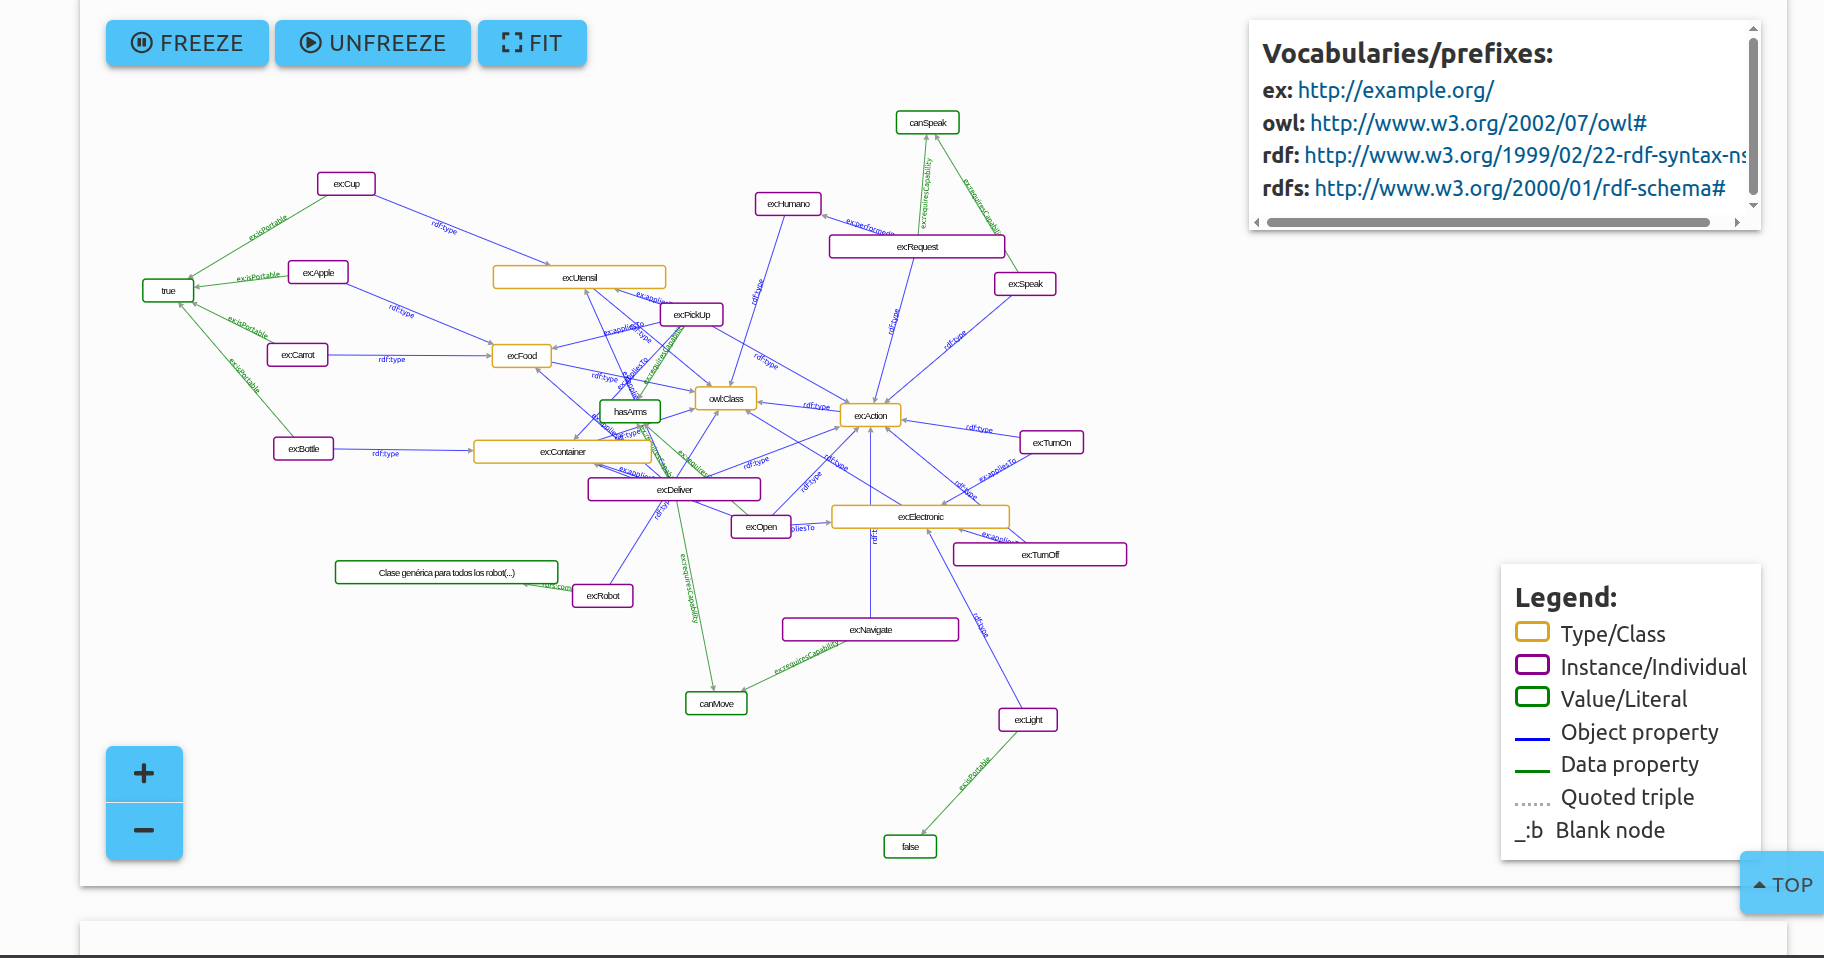
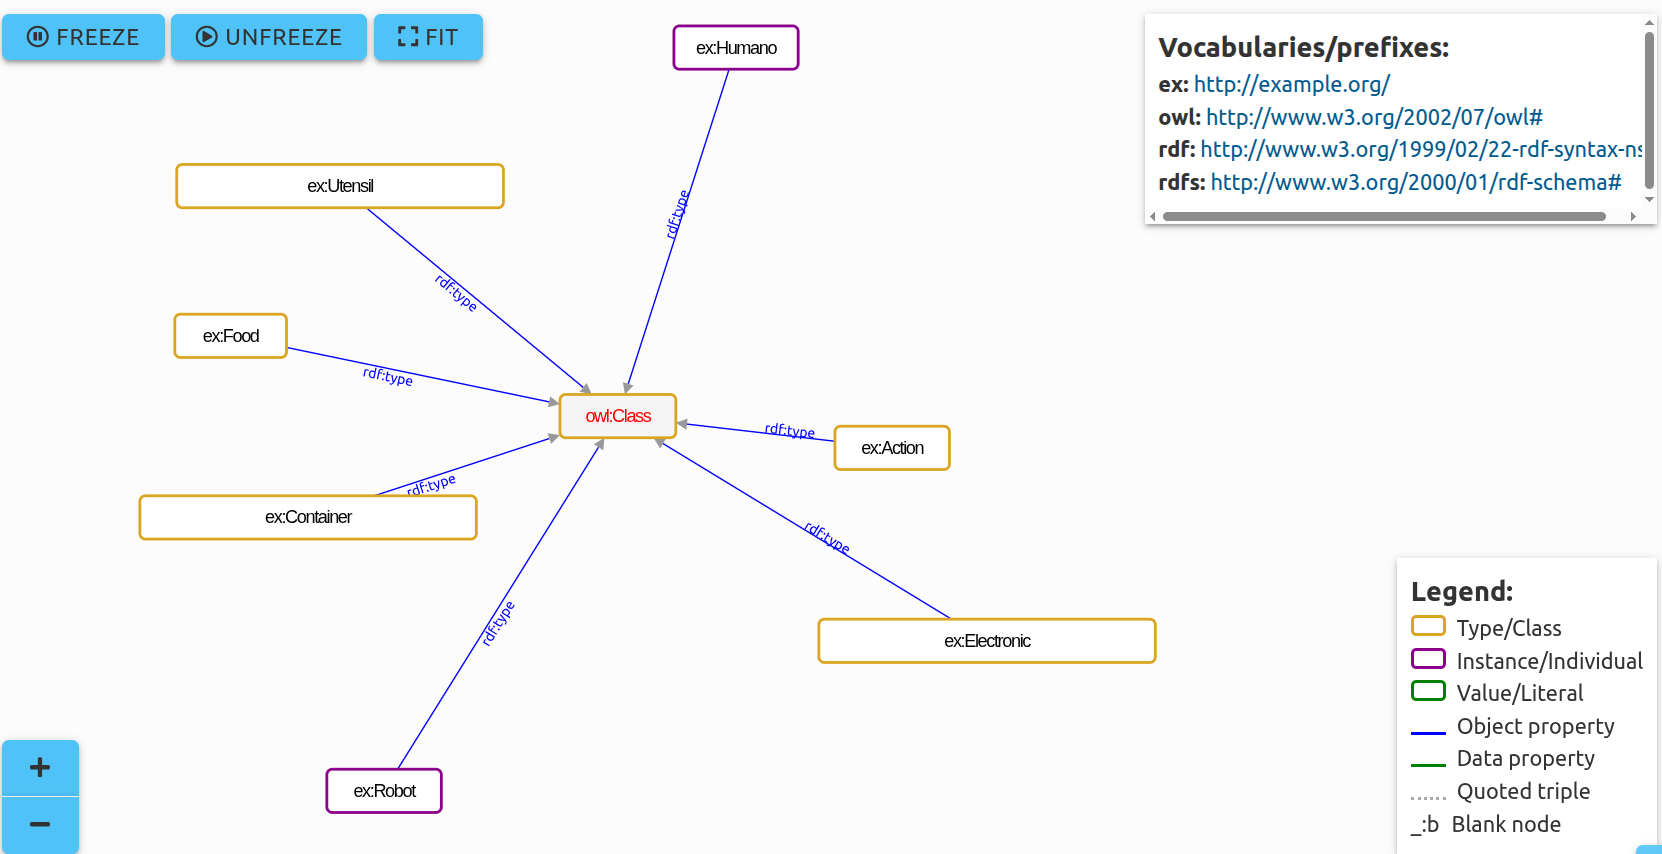
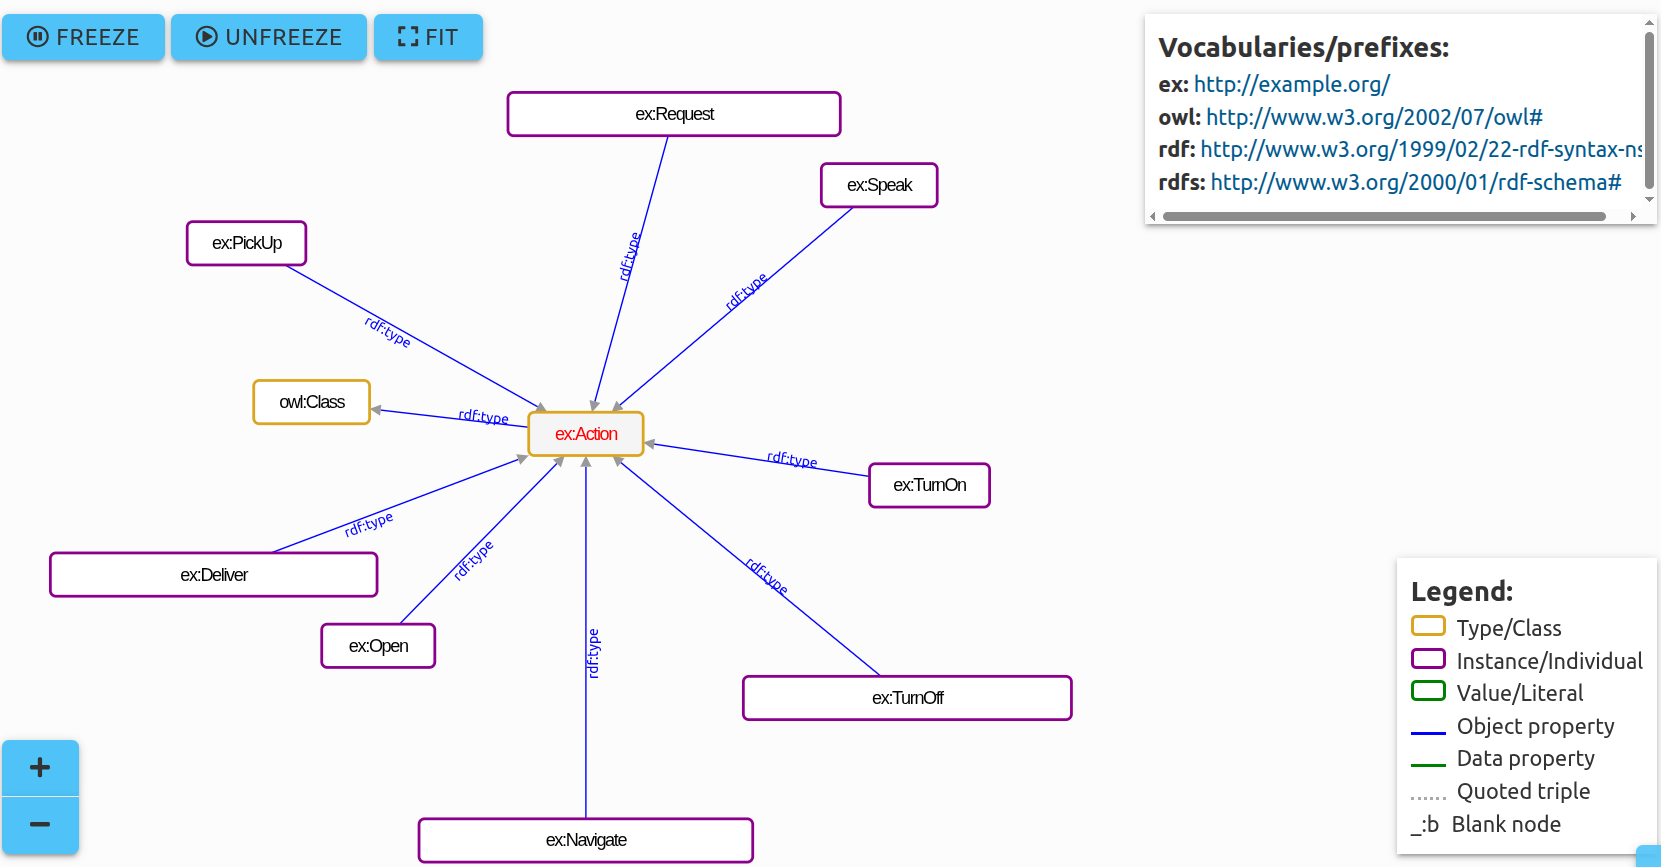
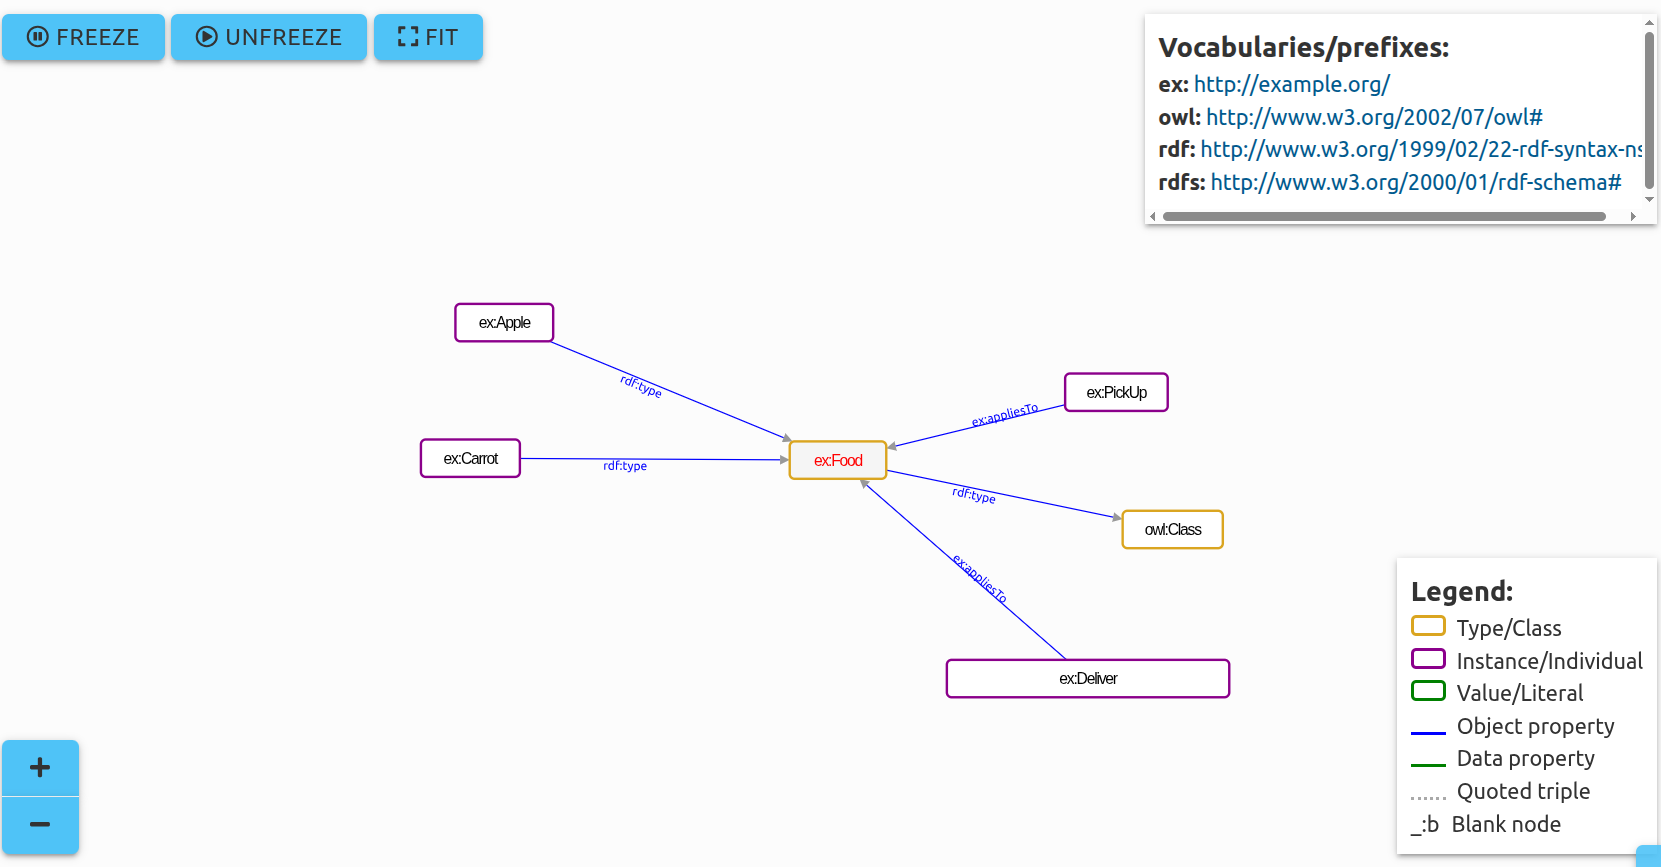
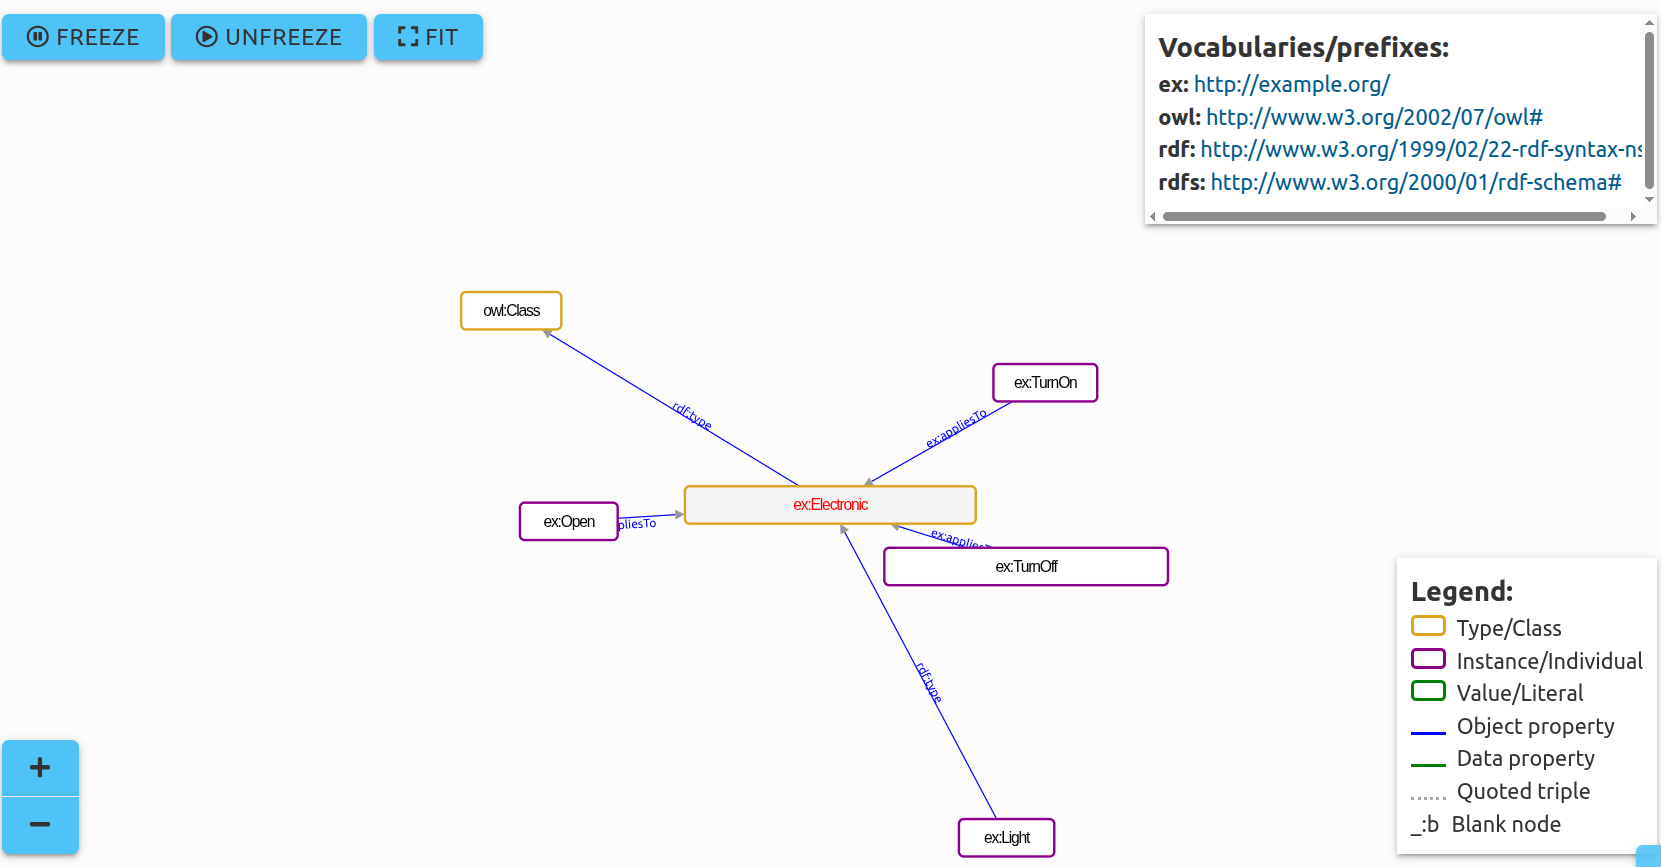
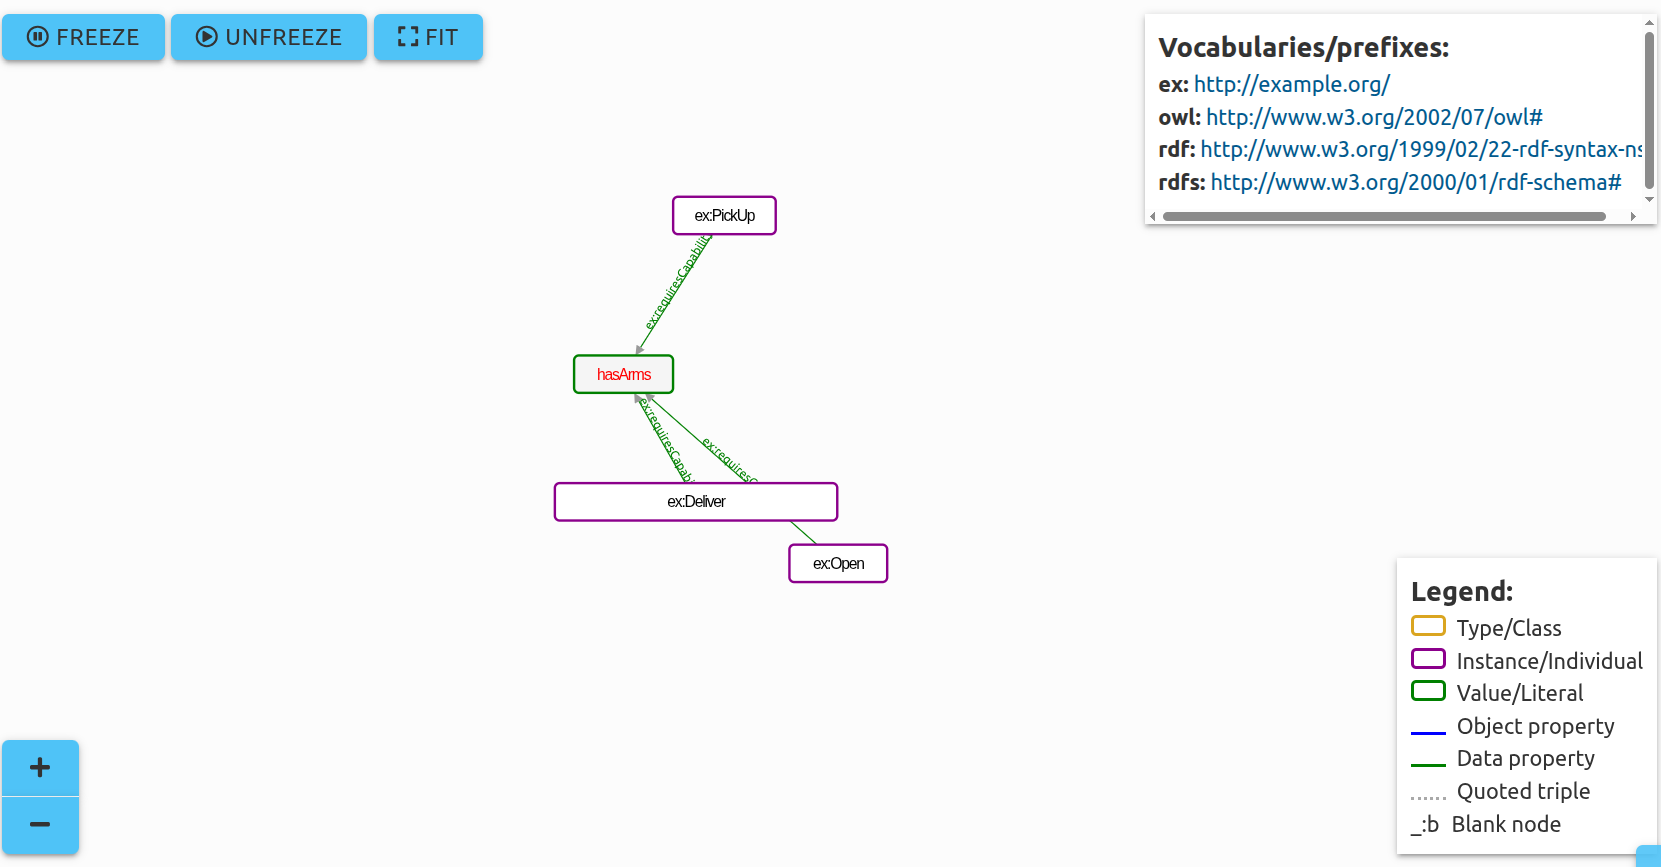
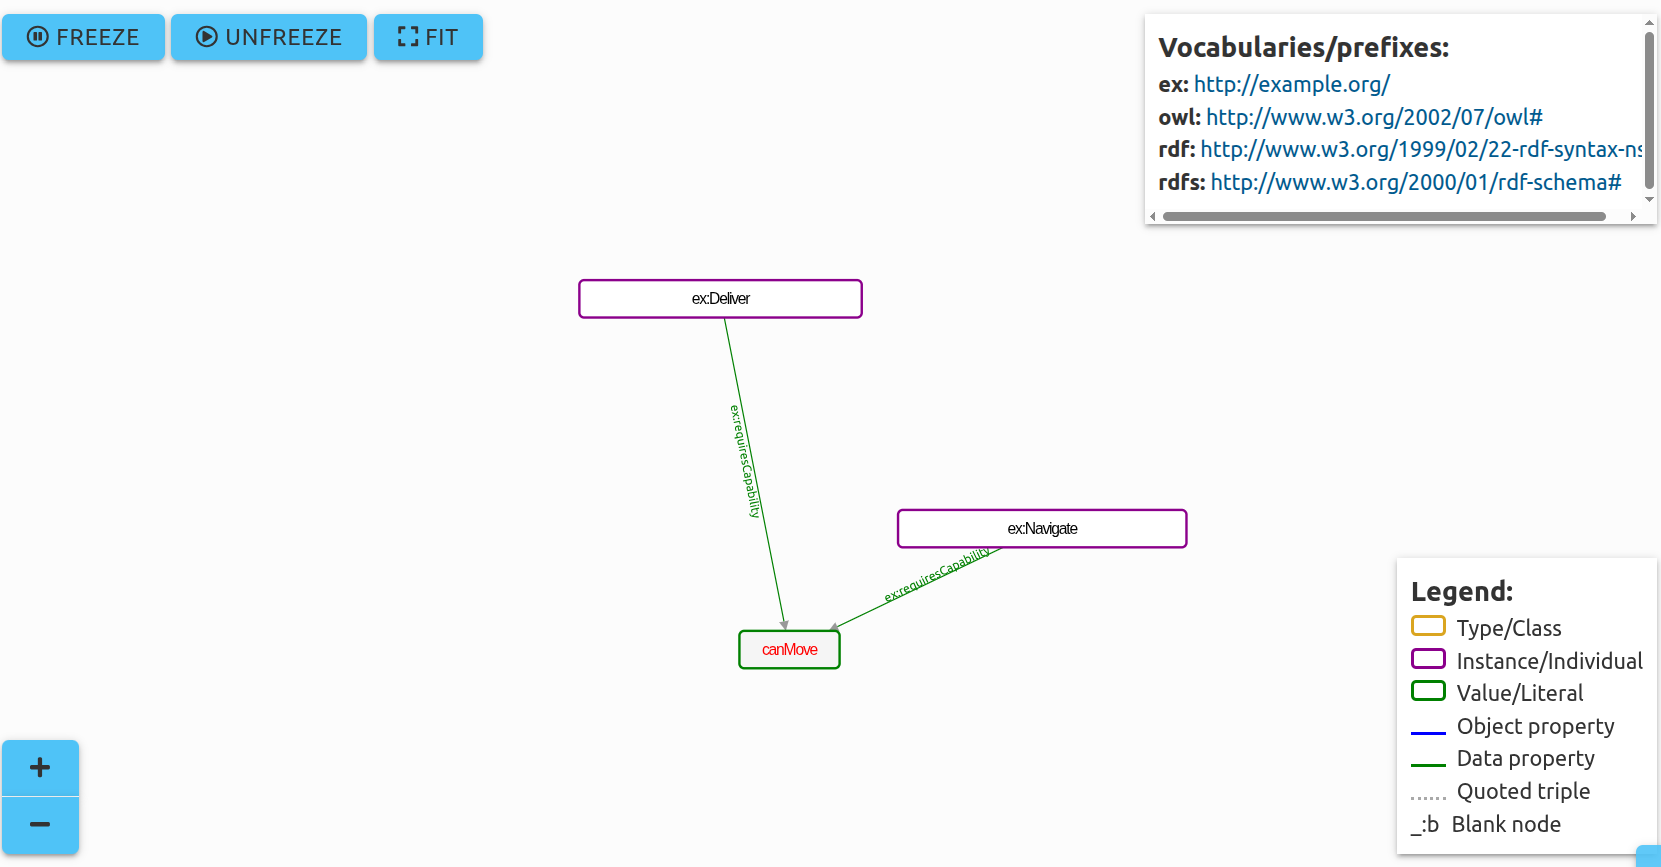
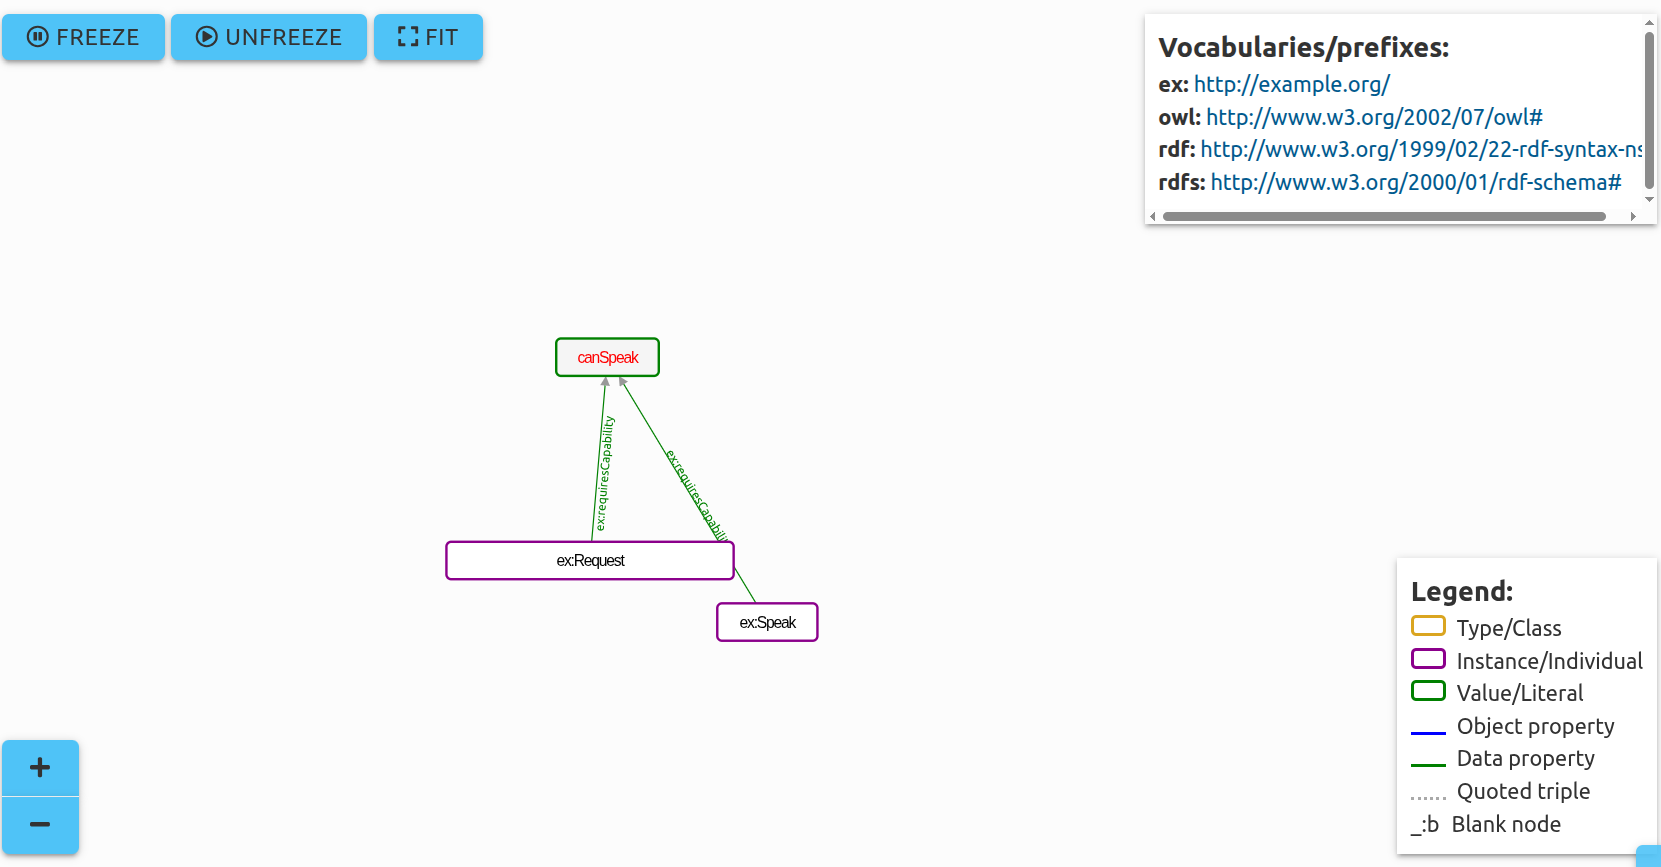

In [101]:
def get_robot_by_capabilities(required_capabilities):
    """
    Encuentra robots que cumplan con las capacidades requeridas.
    required_capabilities: lista de strings como ['canMove', 'hasArms']
    """
    # Construir condiciones dinámicamente
    conditions = " AND ".join([f"r.{cap} = true" for cap in required_capabilities])
    
    query = f"""
    MATCH (r)-[:LOCATED_IN]->(s:Sala)
    WHERE {conditions}
    RETURN r.id AS id, labels(r)[0] AS type, 
           r.canMove AS canMove, r.canSpeak AS canSpeak, r.hasArms AS hasArms,
           r.battery AS battery, s.name AS location
    ORDER BY r.battery DESC
    """
    
    with driver.session() as session:
        result = session.run(query)
        return [dict(record) for record in result]

In [102]:
g = init_sparql_graph()
print(get_actions_for_objects(g))


══════════════════════════════════════════════════
   Ontologia RDF carregada com sucesso!
══════════════════════════════════════════════════
  Total de triplas: 44
══════════════════════════════════════════════════

{'Apple': ['PickUp', 'Deliver'], 'Carrot': ['PickUp', 'Deliver'], 'Cup': ['PickUp', 'Deliver'], 'Bottle': ['PickUp', 'Deliver', 'Open'], 'Light': ['Open', 'TurnOn', 'TurnOff']}


In [103]:
# ============================================
# Paso C. Fusionador Cypher + SPARQL
# ============================================

def hybrid_retriever(room_name, g):
    """
    Fusiona información espacial (Neo4j) con semántica (RDF).
    Retorna objetos en una sala con sus acciones posibles.
    """
    # 1. Obtener objetos en la sala desde Neo4j
    objects = get_objects_by_room(room_name)
    
    # 2. Obtener mapeo de acciones desde RDF
    semantics = get_actions_for_objects(g)
    
    # 3. Enriquecer cada objeto con sus acciones permitidas
    enriched = []
    for obj in objects:
        obj_type = obj["type"]
        actions = semantics.get(obj_type, [])
        enriched.append({
            "id": obj["id"],
            "type": obj_type,
            "room": obj["room"],
            "affords": actions
        })
    return enriched

def get_capable_robot_for_action(action_name, g):
    """
    Encuentra el mejor robot para ejecutar una acción específica.
    Combina requisitos del RDF con capacidades en Neo4j.
    """
    # 1. Obtener requisitos de la acción desde RDF
    requirements = get_action_requirements(g, action_name)
    
    if not requirements:
        # Acción sin requisitos específicos, cualquier robot sirve
        return get_available_robots()
    
    # 2. Buscar robots que cumplan todos los requisitos
    capable_robots = get_robot_by_capabilities(requirements)
    
    return capable_robots

def select_best_robot(task_type, object_type, g):
    """
    Selecciona el robot más adecuado para una tarea.
    
    Prioridades:
    - fetch/deliver: requiere canMove=true y hasArms=true → RobotHumanoide
    - pickup (local): requiere hasArms=true → RobotManipulador o RobotHumanoide
    - speak/notify: requiere canSpeak=true → RobotMovil o RobotHumanoide
    """
    # Mapeo de tareas a acciones RDF
    task_to_action = {
        "fetch": "Deliver",
        "pickup": "PickUp",
        "open": "Open",
        "turn_on": "TurnOn",
        "turn_off": "TurnOff",
        "navigate": "Navigate",
        "speak": "Speak"
    }
    
    action_name = task_to_action.get(task_type, "Navigate")
    
    # Obtener robots capaces
    capable = get_capable_robot_for_action(action_name, g)
    
    if not capable:
        return None
    
    # Ordenar por batería (ya viene ordenado desde la query)
    # Retornar el mejor candidato
    return capable[0] if capable else None

def format_for_llm(enriched_results, room):
    """
    Formatea resultados enriquecidos para el LLM en portugués.
    """
    if not enriched_results:
        return f"Não foram encontrados objetos manipuláveis em {room}."
    
    verb_pt = {
        "PickUp": "pegar",
        "Deliver": "entregar",
        "Open": "abrir",
        "TurnOn": "ligar",
        "TurnOff": "desligar"
    }
    
    lines = []
    for obj in enriched_results:
        actions = obj.get("affords", [])
        if not actions:
            continue
        
        for action in actions:
            action_pt = verb_pt.get(action, action.lower())
            tipo = obj["type"].lower()
            lines.append(f"Em {obj['room']} você pode {action_pt} o/a {tipo} ({obj['id']}).")
    
    return "\n".join(lines)

def get_task_summary(intent, object_id, g):
    """
    Resume qué robots pueden ejecutar la tarea solicitada.
    Combina información semántica (RDF) y espacial (Neo4j).
    """
    # Obtener ubicación del objeto
    loc = get_object_location(object_id)
    if not loc:
        return {"error": f"Objeto {object_id} não encontrado"}
    
    obj_room = loc[0]["room"]
    obj_type = loc[0]["type"]
    
    # Obtener acciones posibles para ese tipo de objeto
    semantics = get_actions_for_objects(g)
    possible_actions = semantics.get(obj_type, [])
    
    # Seleccionar mejor robot para la tarea
    best_robot = select_best_robot(intent, obj_type, g)
    
    if not best_robot:
        return {
            "error": f"Nenhum robô capaz de executar '{intent}' com {obj_type}",
            "object": object_id,
            "location": obj_room,
            "possible_actions": possible_actions
        }
    
    return {
        "object": object_id,
        "object_type": obj_type,
        "location": obj_room,
        "possible_actions": possible_actions,
        "selected_robot": best_robot["id"],
        "robot_type": best_robot["type"],
        "robot_location": best_robot["location"],
        "robot_battery": best_robot["battery"]
    }

In [104]:
# Teste 1: Hybrid Retriever
print(f"\n{Cores.CIANO}{Cores.NEGRITO}{'=' * 70}")
print(f"{'TESTE 1: HYBRID RETRIEVER - OBJETOS EM SALA2'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}\n")

resultado = hybrid_retriever("Sala2", g)
print(f"{Cores.AZUL}Objetos encontrados:{Cores.RESET} {len(resultado)}\n")
for obj in resultado:
    print(f"{Cores.VERDE}  • {obj['id']}{Cores.RESET} ({obj['type']}) em {obj['room']}")
    print(f"{Cores.AMARELO}    Ações permitidas:{Cores.RESET} {obj['affords']}")

# Teste 2: Robôs Capazes de Executar Ações
print(f"\n{Cores.CIANO}{Cores.NEGRITO}{'=' * 70}")
print(f"{'TESTE 2: ROBÔS CAPAZES POR AÇÃO'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}\n")

acoes_teste = ["PickUp", "Deliver", "Speak", "Navigate"]
for acao in acoes_teste:
    print(f"{Cores.AZUL}Ação:{Cores.RESET} {acao}")
    robos = get_capable_robot_for_action(acao, g)
    if robos:
        for robot in robos:
            print(f"{Cores.VERDE}  ✓ {robot['id']}{Cores.RESET} ({robot['type']}) - Bateria: {robot['battery']}%")
    else:
        print(f"{Cores.VERMELHO}  ✗ Nenhum robô capaz{Cores.RESET}")
    print()



             TESTE 1: HYBRID RETRIEVER - OBJETOS EM SALA2             

Objetos encontrados: 3

  • RobotMovil (RobotMovil) em Sala2
    Ações permitidas: []
  • cup1 (Cup) em Sala2
    Ações permitidas: ['PickUp', 'Deliver']
  • apple1 (Apple) em Sala2
    Ações permitidas: ['PickUp', 'Deliver']

                   TESTE 2: ROBÔS CAPAZES POR AÇÃO                    

Ação: PickUp
  ✓ RobotFijo (RobotManipulador) - Bateria: 100%
  ✓ RobotHumanoide (RobotHumanoide) - Bateria: 70%

Ação: Deliver
  ✓ RobotHumanoide (RobotHumanoide) - Bateria: 70%

Ação: Speak
  ✓ Ervin (Humano) - Bateria: None%
  ✓ RobotMovil (RobotMovil) - Bateria: 85%
  ✓ RobotHumanoide (RobotHumanoide) - Bateria: 70%

Ação: Navigate
  ✓ RobotMovil (RobotMovil) - Bateria: 85%
  ✓ RobotHumanoide (RobotHumanoide) - Bateria: 70%



In [105]:
# Teste 3: Seleção do Melhor Robô
print(f"{Cores.CIANO}{Cores.NEGRITO}{'=' * 70}")
print(f"{'TESTE 3: SELEÇÃO DO MELHOR ROBÔ POR TAREFA'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}\n")

tarefas_teste = [
    ("fetch", "Apple"),
    ("pickup", "Cup"),
    ("speak", "Light"),
    ("turn_on", "Light")
]
for tarefa, objeto_tipo in tarefas_teste:
    print(f"{Cores.AZUL}Tarefa:{Cores.RESET} {tarefa} com {objeto_tipo}")
    melhor = select_best_robot(tarefa, objeto_tipo, g)
    if melhor:
        print(f"{Cores.VERDE}  → Robô selecionado:{Cores.RESET} {melhor['id']} ({melhor['type']})")
        print(f"{Cores.AMARELO}    Localização:{Cores.RESET} {melhor['location']}, {Cores.AMARELO}Bateria:{Cores.RESET} {melhor['battery']}%")
    else:
        print(f"{Cores.VERMELHO}  → Nenhum robô adequado encontrado{Cores.RESET}")
    print()

# Teste 4: Formatação para LLM
print(f"{Cores.CIANO}{Cores.NEGRITO}{'=' * 70}")
print(f"{'TESTE 4: FORMATAÇÃO PARA LLM'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}\n")

resultado_sala3 = hybrid_retriever("Sala3", g)
texto_formatado = format_for_llm(resultado_sala3, "Sala3")
print(f"{Cores.VERDE}{texto_formatado}{Cores.RESET}\n")

# Teste 5: Resumo de Tarefa - Integração Completa
print(f"{Cores.CIANO}{Cores.NEGRITO}{'=' * 70}")
print(f"{'TESTE 5: RESUMO DE TAREFA - INTEGRAÇÃO COMPLETA'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}\n")

objetos_teste = ["apple1", "cup1", "light1", "bottle1", "objeto_inexistente"]
for obj_id in objetos_teste:
    print(f"{Cores.MAGENTA}Objeto:{Cores.RESET} {obj_id}")
    print(f"{Cores.CIANO}{'-' * 70}{Cores.RESET}")
    
    resumo = get_task_summary("fetch", obj_id, g)
    
    if "error" in resumo:
        print(f"{Cores.VERMELHO}  ✗ ERRO:{Cores.RESET} {resumo['error']}")
    else:
        print(f"{Cores.AMARELO}  Tipo:{Cores.RESET} {resumo['object_type']}")
        print(f"{Cores.AMARELO}  Localização:{Cores.RESET} {resumo['location']}")
        print(f"{Cores.AMARELO}  Ações possíveis:{Cores.RESET} {resumo['possible_actions']}")
        print(f"{Cores.VERDE}  Robô selecionado:{Cores.RESET} {resumo['selected_robot']} ({resumo['robot_type']})")
        print(f"{Cores.VERDE}  Robô em:{Cores.RESET} {resumo['robot_location']}, {Cores.VERDE}Bateria:{Cores.RESET} {resumo['robot_battery']}%")
    print()

# Teste 6: Casos Extremos
print(f"{Cores.CIANO}{Cores.NEGRITO}{'=' * 70}")
print(f"{'TESTE 6: CASOS EXTREMOS'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}\n")

print(f"{Cores.AZUL}Caso 1: Sala inexistente{Cores.RESET}")
resultado_vazio = hybrid_retriever("SalaInexistente", g)
print(f"{Cores.AMARELO}{format_for_llm(resultado_vazio, 'SalaInexistente')}{Cores.RESET}\n")

print(f"{Cores.AZUL}Caso 2: Tarefa sem robô capaz{Cores.RESET}")
resumo_impossivel = get_task_summary("navigate", "cup1", g)
print(f"{Cores.VERMELHO}{resumo_impossivel}{Cores.RESET}\n")

              TESTE 3: SELEÇÃO DO MELHOR ROBÔ POR TAREFA              

Tarefa: fetch com Apple
  → Robô selecionado: RobotHumanoide (RobotHumanoide)
    Localização: Sala3, Bateria: 70%

Tarefa: pickup com Cup
  → Robô selecionado: RobotFijo (RobotManipulador)
    Localização: Sala1, Bateria: 100%

Tarefa: speak com Light
  → Robô selecionado: Ervin (Humano)
    Localização: Sala1, Bateria: None%

Tarefa: turn_on com Light
  → Robô selecionado: RobotFijo (RobotManipulador)
    Localização: Sala1, Bateria: 100%

                     TESTE 4: FORMATAÇÃO PARA LLM                     



Em Sala3 você pode pegar o/a carrot (carrot1).
Em Sala3 você pode entregar o/a carrot (carrot1).
Em Sala3 você pode pegar o/a bottle (bottle1).
Em Sala3 você pode entregar o/a bottle (bottle1).
Em Sala3 você pode abrir o/a bottle (bottle1).

           TESTE 5: RESUMO DE TAREFA - INTEGRAÇÃO COMPLETA            

Objeto: apple1
----------------------------------------------------------------------
  Tipo: Apple
  Localização: Sala2
  Ações possíveis: ['PickUp', 'Deliver']
  Robô selecionado: RobotHumanoide (RobotHumanoide)
  Robô em: Sala3, Bateria: 70%

Objeto: cup1
----------------------------------------------------------------------
  Tipo: Cup
  Localização: Sala2
  Ações possíveis: ['PickUp', 'Deliver']
  Robô selecionado: RobotHumanoide (RobotHumanoide)
  Robô em: Sala3, Bateria: 70%

Objeto: light1
----------------------------------------------------------------------
  Tipo: Light
  Localização: Sala1
  Ações possíveis: ['Open', 'TurnOn', 'TurnOff']
  Robô selecionado: RobotHum

In [ ]:
# ============================================
# Paso D. Capa LLM/RAG con Groq
# ============================================

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.0,
    max_retries=2,
    groq_api_key=GROQ_API_KEY,
)

def ask_robot(room, g):
    """
    Consulta qué puede hacer el robot en una sala específica.
    Combina información del grafo con generación de lenguaje natural.
    """
    results = hybrid_retriever(room, g)
    structured_info = format_for_llm(results, room)
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Você é um assistente robótico que traduz estados de um grafo para linguagem natural clara em português."),
        ("user", "Aqui estão os objetos e ações disponíveis:\n{info}\n\nResponda em uma frase natural.")
    ])
    
    chain = prompt | llm
    response = chain.invoke({"info": structured_info})
    return response.content

def ask_for_object(object_id, g):
    """
    Consulta información sobre un objeto específico y qué puede hacer el robot.
    """
    # Obtener ubicación del objeto
    loc = get_object_location(object_id)
    if not loc:
        return f"Não encontrei o objeto {object_id}."
    
    room = loc[0]["room"]
    obj_type = loc[0]["type"]
    
    # Obtener acciones semánticas posibles
    semantics = get_actions_for_objects(g)
    actions = semantics.get(obj_type, [])
    
    # Obtener camino desde un robot (usar el primero disponible)
    available_robots = get_available_robots()
    if not available_robots:
        return "Nenhum robô disponível no sistema."
    
    robot_id = available_robots[0]["id"]
    path = get_path_to_object(robot_id, object_id)
    
    # Generar respuesta con LLM
    actions_text = ", ".join(actions) if actions else "nenhuma ação conhecida"
    path_text = " → ".join(path['rooms']) if path else "desconhecido"
    
    info = f"O objeto {object_id} ({obj_type}) está em {room}. " \
           f"Ações possíveis: {actions_text}. " \
           f"Caminho sugerido desde {robot_id}: {path_text}."
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Você é um planejador de ações robóticas. Responda em português de forma clara."),
        ("user", "Resumo do ambiente:\n{info}\n\nResponda o que o robô pode fazer em linguagem natural.")
    ])
    
    chain = prompt | llm
    return chain.invoke({"info": info}).content

def explain_robot_selection(task_summary):
    """
    Genera explicación en lenguaje natural sobre qué robot fue seleccionado y por qué.
    """
    if "error" in task_summary:
        prompt = ChatPromptTemplate.from_messages([
            ("system", "Você é um assistente robótico que explica limitações do sistema em português."),
            ("user", "Erro: {error}\nObjeto: {object}\nLocalização: {location}\nAções possíveis: {actions}\n\nExplique ao usuário por que a tarefa não pode ser executada.")
        ])
        
        chain = prompt | llm
        return chain.invoke({
            "error": task_summary.get("error", "Erro desconhecido"),
            "object": task_summary.get("object", "N/A"),
            "location": task_summary.get("location", "N/A"),
            "actions": ", ".join(task_summary.get("possible_actions", []))
        }).content
    
    # Caso exitoso
    info = f"""
Robot selecionado: {task_summary['selected_robot']} (tipo: {task_summary['robot_type']})
Bateria: {task_summary['robot_battery']}%
Localização atual: {task_summary['robot_location']}

Objeto alvo: {task_summary['object']} (tipo: {task_summary['object_type']})
Localização do objeto: {task_summary['location']}
Ações possíveis: {', '.join(task_summary['possible_actions'])}
"""
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Você é um assistente robótico que explica decisões de planejamento em português de forma amigável."),
        ("user", "Informação da tarefa:\n{info}\n\nExplique ao usuário qual robô foi escolhido e por quê, de forma natural e concisa.")
    ])
    
    chain = prompt | llm
    return chain.invoke({"info": info}).content

**Comparação Visual das Funções**
```markdown
┌─────────────────────────────┬──────────────────┬────────────────────────────────────────┐
│ Função                      │ Input            │ Output                                 │
├─────────────────────────────┼──────────────────┼────────────────────────────────────────┤
│ ask_robot()                 │ Nome da sala     │ "Nesta sala você pode fazer X, Y, Z"   │
├─────────────────────────────┼──────────────────┼────────────────────────────────────────┤
│ ask_for_object()            │ ID do objeto     │ "O objeto está em X, você pode fazer Y"│
├─────────────────────────────┼──────────────────┼────────────────────────────────────────┤
│ explain_robot_selection()   │ Resumo da tarefa │ "Escolhi Robot X porque..." ou         │
│                             │                  │ "Não posso porque..."                  │
└─────────────────────────────┴──────────────────┴────────────────────────────────────────┘
```

In [107]:
# Teste 1: ask_robot()
print(f"\n{Cores.CIANO}{Cores.NEGRITO}{'=' * 70}")
print(f"{'TESTE 1: CONSULTA SOBRE SALA'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}\n")

sala_teste = "Sala2"
print(f"{Cores.AZUL}Pergunta:{Cores.RESET} O que posso fazer na {sala_teste}?")
resposta = ask_robot(sala_teste, g)
print(f"\n{Cores.VERDE}Resposta do LLM:{Cores.RESET}")
print(f"{Cores.VERDE}{resposta}{Cores.RESET}\n")

# Teste 2: ask_for_object()
print(f"{Cores.CIANO}{Cores.NEGRITO}{'=' * 70}")
print(f"{'TESTE 2: CONSULTA SOBRE OBJETO'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}\n")

objeto_teste = "apple1"
print(f"{Cores.AZUL}Pergunta:{Cores.RESET} O que posso fazer com {objeto_teste}?")
resposta = ask_for_object(objeto_teste, g)
print(f"\n{Cores.VERDE}Resposta do LLM:{Cores.RESET}")
print(f"{Cores.VERDE}{resposta}{Cores.RESET}\n")

# Teste 3: explain_robot_selection() - Sucesso
print(f"{Cores.CIANO}{Cores.NEGRITO}{'=' * 70}")
print(f"{'TESTE 3: EXPLICAÇÃO DE SELEÇÃO - SUCESSO'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}\n")

resumo_sucesso = get_task_summary("fetch", "cup1", g)
print(f"{Cores.AMARELO}Resumo da tarefa gerado:{Cores.RESET}")
print(f"{Cores.AMARELO}{resumo_sucesso}{Cores.RESET}\n")

explicacao = explain_robot_selection(resumo_sucesso)
print(f"{Cores.VERDE}Explicação do LLM:{Cores.RESET}")
print(f"{Cores.VERDE}{explicacao}{Cores.RESET}\n")

# Teste 4: explain_robot_selection() - Erro
print(f"{Cores.CIANO}{Cores.NEGRITO}{'=' * 70}")
print(f"{'TESTE 4: EXPLICAÇÃO DE SELEÇÃO - ERRO'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}\n")

resumo_erro = {
    "error": "Nenhum robô capaz de executar 'voar' com Apple",
    "object": "apple1",
    "location": "Sala2",
    "possible_actions": ["PickUp", "Deliver"]
}
print(f"{Cores.VERMELHO}Resumo com erro:{Cores.RESET}")
print(f"{Cores.VERMELHO}{resumo_erro}{Cores.RESET}\n")

explicacao_erro = explain_robot_selection(resumo_erro)
print(f"{Cores.AMARELO}Explicação do LLM:{Cores.RESET}")
print(f"{Cores.AMARELO}{explicacao_erro}{Cores.RESET}\n")


                     TESTE 1: CONSULTA SOBRE SALA                     

Pergunta: O que posso fazer na Sala2?

Resposta do LLM:
Na Sala2, você tem a opção de pegar ou entregar tanto a xícara (cup1) quanto a maçã (apple1).

                    TESTE 2: CONSULTA SOBRE OBJETO                    

Pergunta: O que posso fazer com apple1?

Resposta do LLM:
O robô pode se mover de Sala1 para Sala2, onde está localizado o objeto "apple1" (uma maçã). Uma vez em Sala2, o robô pode realizar a ação "PickUp" para pegar a maçã. Após pegar a maçã, o robô pode realizar a ação "Deliver" para entregar a maçã em um local específico.

               TESTE 3: EXPLICAÇÃO DE SELEÇÃO - SUCESSO               

Resumo da tarefa gerado:
{'object': 'cup1', 'object_type': 'Cup', 'location': 'Sala2', 'possible_actions': ['PickUp', 'Deliver'], 'selected_robot': 'RobotHumanoide', 'robot_type': 'RobotHumanoide', 'robot_location': 'Sala3', 'robot_battery': 70}

Explicação do LLM:
Olá! Estou aqui para ajudar com a tare

In [108]:
# # ============================================
# # Paso 0.1 Reglas Multilingües
# # ============================================
# import json
# from difflib import get_close_matches

# # Diccionarios multilingües actualizados
# OBJECT_MAP = {
#     # Español
#     "manzana": "apple1",
#     "taza": "cup1",
#     "copo": "cup1",
#     "luz": "light1",
#     "botella": "bottle1",
#     "zanahoria": "carrot1",
    
#     # Inglés
#     "apple": "apple1",
#     "cup": "cup1",
#     "light": "light1",
#     "bottle": "bottle1",
#     "carrot": "carrot1",
    
#     # Portugués
#     "maçã": "apple1",
#     "maca": "apple1",
#     "xícara": "cup1",
#     "xicara": "cup1",
#     "garrafa": "bottle1",
#     "cenoura": "carrot1"
# }

# INTENT_KEYWORDS = {
#     # Español
#     "tráeme": "fetch",
#     "traeme": "fetch",
#     "traer": "fetch",
#     "alcanza": "fetch",
#     "alcanzar": "fetch",
#     "abre": "open",
#     "abrir": "open",
#     "enciende": "turn_on",
#     "encender": "turn_on",
#     "apaga": "turn_off",
#     "apagar": "turn_off",
#     "posición": "query_location",
#     "posicion": "query_location",
#     "dónde": "query_location",
#     "donde": "query_location",
#     "ubicación": "query_location",
#     "ubicacion": "query_location",
    
#     # Inglés
#     "bring": "fetch",
#     "get": "fetch",
#     "fetch": "fetch",
#     "open": "open",
#     "turn on": "turn_on",
#     "switch on": "turn_on",
#     "turn off": "turn_off",
#     "switch off": "turn_off",
#     "where": "query_location",
#     "location": "query_location",
    
#     # Portugués
#     "traz": "fetch",
#     "traga": "fetch",
#     "trazer": "fetch",
#     "pegue": "fetch",
#     "pegar": "fetch",
#     "buscar": "fetch",
#     "abra": "open",
#     "abrir": "open",
#     "acenda": "turn_on",
#     "acender": "turn_on",
#     "ligue": "turn_on",
#     "ligar": "turn_on",
#     "apague": "turn_off",
#     "apagar": "turn_off",
#     "desligue": "turn_off",
#     "desligar": "turn_off",
#     "localização": "query_location",
#     "localizacao": "query_location",
#     "onde": "query_location"
# }

# def correct_word(word, vocab):
#     """Corrige ortografía usando fuzzy matching."""
#     matches = get_close_matches(word, vocab, n=1, cutoff=0.75)
#     return matches[0] if matches else word

# def rule_based_nlu(user_text: str):
#     """NLU basado en reglas con corrección ortográfica."""
#     text = user_text.lower()
    
#     # Corrección ortográfica ligera
#     tokens = text.split()
#     all_vocab = list(OBJECT_MAP.keys()) + list(INTENT_KEYWORDS.keys())
#     tokens = [correct_word(t, all_vocab) for t in tokens]
#     text_corrected = " ".join(tokens)
    
#     # Detectar intent
#     intent = None
#     for keyword, intent_value in INTENT_KEYWORDS.items():
#         if keyword in text_corrected:
#             intent = intent_value
#             break
    
#     # Detectar object
#     obj = None
#     for keyword, obj_id in OBJECT_MAP.items():
#         if keyword in text_corrected:
#             obj = obj_id
#             break
    
#     # Detectar destino (opcional)
#     destination = None
#     if "sala1" in text_corrected:
#         destination = "Sala1"
#     elif "sala2" in text_corrected:
#         destination = "Sala2"
#     elif "sala3" in text_corrected:
#         destination = "Sala3"
    
#     return {
#         "intent": intent or "unknown",
#         "object": obj or "unknown",
#         "destination": destination
#     }

In [109]:
# # ============================================
# # Paso 0.2 Fallback con LLM
# # ============================================

# llm_nlu_model = ChatGroq(
#     model="llama-3.3-70b-versatile",
#     temperature=0.0,
#     max_retries=2,
#     groq_api_key=GROQ_API_KEY,
# )

# prompt_nlu = ChatPromptTemplate.from_messages([
#     ("system",
#      "Você é um intérprete multilíngue (espanhol, português, inglês). "
#      "Retorne JSON válido com campos: intent, object, destination. "
#      "\nPossíveis intents: fetch, open, turn_on, turn_off, query_location. "
#      "\nPossíveis objetos: apple1, cup1, light1, bottle1, carrot1. "
#      "\nPossíveis destinos: Sala1, Sala2, Sala3. "
#      "\nVocê deve corrigir erros ortográficos menores e entender sinônimos comuns. "
#      "\nSe não houver destino mencionado, use null. "
#      "\nExemplo de resposta: {\"intent\": \"fetch\", \"object\": \"apple1\", \"destination\": \"Sala1\"}"),
#     ("user", "Ordem do usuário: {text}")
# ])

# def llm_nlu(user_text):
#     """Fallback NLU usando LLM cuando las reglas fallan."""
#     chain = prompt_nlu | llm_nlu_model
#     response = chain.invoke({"text": user_text}).content
    
#     try:
#         # Limpiar respuesta si viene envuelta en markdown
#         if "```json" in response:
#             response = response.split("```json")[1].split("```")[0].strip()
#         elif "```" in response:
#             response = response.split("```")[1].split("```")[0].strip()
        
#         parsed = json.loads(response)
#         return parsed
#     except Exception as e:
#         print(f"⚠️ Error parseando respuesta LLM: {e}")
#         print(f"Respuesta recibida: {response}")
#         return {"intent": "unknown", "object": "unknown", "destination": None}

# def nlu(user_text: str):
#     """
#     NLU híbrido: Intenta reglas primero, luego fallback a LLM.
#     Retorna: {"intent": str, "object": str, "destination": str|None}
#     """
#     result = rule_based_nlu(user_text)
    
#     # Si las reglas no encontraron intent u object, usar LLM
#     if result["intent"] == "unknown" or result["object"] == "unknown":
#         print("⚠️ Reglas insuficientes, usando fallback LLM...")
#         return llm_nlu(user_text)
    
#     return result

In [110]:
# ============================================
# Paso E. Planificador Híbrido
# ============================================

ACTION_TRANSLATION = {
    "PickUp": "pegar",
    "Deliver": "entregar",
    "Open": "abrir",
    "TurnOn": "ligar",
    "TurnOff": "desligar",
    "Navigate": "navegar"
}

def generate_plan(intent, robot_id, object_id, g, dest_room=None):
    """
    Genera plan simbólico y narrativa en lenguaje natural.
    
    Args:
        intent: Intención del usuario (fetch, open, turn_on, etc.)
        robot_id: ID del robot seleccionado (puede ser None para auto-selección)
        object_id: ID del objeto objetivo
        g: Grafo RDF
        dest_room: Sala de destino (opcional)
    
    Returns:
        dict con "plan" (lista de pasos simbólicos) y "natural" (narrativa en lenguaje natural)
    """
    
    # 1. Obtener ubicación del objeto
    loc = get_object_location(object_id)
    if not loc:
        return {
            "plan": [],
            "natural": f"Não encontrei o objeto {object_id}.",
            "error": "object_not_found"
        }
    
    obj_room = loc[0]["room"]
    obj_type = loc[0]["type"]
    
    # 2. Auto-seleccionar robot si no se especificó
    if not robot_id:
        task_summary = get_task_summary(intent, object_id, g)
        if "error" in task_summary:
            return {
                "plan": [],
                "natural": task_summary["error"],
                "error": "no_capable_robot"
            }
        robot_id = task_summary["selected_robot"]
    
    # 3. Obtener información del robot
    robot_info_list = get_available_robots()
    robot_info = next((r for r in robot_info_list if r["id"] == robot_id), None)
    
    if not robot_info:
        return {
            "plan": [],
            "natural": f"Robô {robot_id} não encontrado ou não disponível.",
            "error": "robot_not_found"
        }
    
    # 4. Verificar capacidades del robot para la tarea
    can_move = robot_info.get("canMove", False)
    can_speak = robot_info.get("canSpeak", False)
    has_arms = robot_info.get("hasArms", False)
    robot_location = robot_info.get("location", "Unknown")
    
    # 5. Obtener acciones semánticas posibles (SPARQL)
    semantics = get_actions_for_objects(g)
    actions = semantics.get(obj_type, [])
    
    # 6. Obtener camino si el robot puede moverse
    path = None
    path_str = "no disponible (robot fijo)"
    if can_move:
        path = get_path_to_object(robot_id, object_id)
        path_str = " → ".join(path['rooms']) if path else "desconocido"
    
    # 7. Generar plan simbólico según intención
    plan = []
    
    if intent == "fetch":
        # Verificar que el robot pueda realizar fetch
        if not can_move:
            return {
                "plan": [],
                "natural": f"O robô {robot_id} não pode se mover para buscar objetos.",
                "error": "robot_cannot_move"
            }
        if not has_arms:
            return {
                "plan": [],
                "natural": f"O robô {robot_id} não tem braços para pegar objetos.",
                "error": "robot_no_arms"
            }
        
        # Plan para fetch
        if robot_location != obj_room:
            plan.append(f"Navigate({robot_id}, {robot_location} → {obj_room})")
        
        if "PickUp" in actions:
            plan.append(f"PickUp({robot_id}, {object_id})")
        
        # Ir al destino
        if dest_room and dest_room != obj_room:
            plan.append(f"Navigate({robot_id}, {obj_room} → {dest_room})")
        elif not dest_room:
            dest_room = "Sala1"  # Default: llevar a Sala1 (donde está Ervin)
            plan.append(f"Navigate({robot_id}, {obj_room} → {dest_room})")
        
        if "Deliver" in actions:
            plan.append(f"Deliver({robot_id}, {object_id}, Ervin)")
        
        if can_speak:
            plan.append(f'Speak({robot_id}, "Aqui está seu {obj_type.lower()}, Ervin")')
    
    elif intent == "open":
        # El robot debe ir al objeto si puede moverse
        if can_move and robot_location != obj_room:
            plan.append(f"Navigate({robot_id}, {robot_location} → {obj_room})")
        elif not can_move and robot_location != obj_room:
            return {
                "plan": [],
                "natural": f"O robô {robot_id} está em {robot_location} e não pode se mover até {obj_room}.",
                "error": "robot_cannot_reach"
            }
        
        if "Open" in actions and has_arms:
            plan.append(f"Open({robot_id}, {object_id})")
        elif not has_arms:
            return {
                "plan": [],
                "natural": f"O robô {robot_id} não tem braços para abrir objetos.",
                "error": "robot_no_arms"
            }
    
    elif intent in ["turn_on", "turn_off"]:
        action_name = "TurnOn" if intent == "turn_on" else "TurnOff"
        
        if can_move and robot_location != obj_room:
            plan.append(f"Navigate({robot_id}, {robot_location} → {obj_room})")
        elif not can_move and robot_location != obj_room:
            return {
                "plan": [],
                "natural": f"O robô {robot_id} está em {robot_location} e não pode se mover até {obj_room}.",
                "error": "robot_cannot_reach"
            }
        
        if action_name in actions:
            plan.append(f"{action_name}({robot_id}, {object_id})")
    
    elif intent == "query_location":
        plan.append(f"QueryLocation({robot_id}, {object_id})")
        if can_speak:
            plan.append(f'Speak({robot_id}, "O {obj_type.lower()} está em {obj_room}")')
        
        return {
            "plan": plan,
            "natural": f"O {obj_type} {object_id} está em {obj_room}."
        }
    
    else:
        plan.append(f"# Intenção '{intent}' não suportada")
        return {
            "plan": plan,
            "natural": f"Desculpe, não sei como executar a ação '{intent}'.",
            "error": "unsupported_intent"
        }
    
    # 8. Generar narrativa en lenguaje natural con LLM
    actions_text = ", ".join(actions) if actions else "nenhuma ação conhecida"
    
    info = f"""
Robô selecionado: {robot_id} ({robot_info['type']})
Localização atual: {robot_location}
Capacidades: movimento={can_move}, fala={can_speak}, braços={has_arms}
Bateria: {robot_info['battery']}%

Objeto: {object_id} ({obj_type})
Localização do objeto: {obj_room}
Ações possíveis: {actions_text}
Caminho: {path_str}

Plano gerado:
{chr(10).join(f"  {i+1}. {step}" for i, step in enumerate(plan))}
"""
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Você é um narrador de planos robóticos. Traduza o plano simbólico em uma narrativa clara e amigável em português, explicando o que o robô fará passo a passo."),
        ("user", "Informação do plano:\n{info}\n\nCrie uma narrativa natural do que acontecerá.")
    ])
    
    chain = prompt | llm
    natural = chain.invoke({"info": info}).content
    
    return {
        "plan": plan,
        "natural": natural,
        "robot": robot_id,
        "object": object_id,
        "path": path_str
    }

In [111]:
# ============================================
# Agente Conversacional NLU
# ============================================

class ContextoConversa:
    def __init__(self):
        self.historico = []
        self.aguardando_confirmacao = False
        self.plano_pendente = None
    
    def adicionar(self, papel, conteudo):
        self.historico.append({"papel": papel, "conteudo": conteudo})
        if len(self.historico) > 10:
            self.historico.pop(0)
    
    def get_texto_historico(self):
        return "\n".join([f"{msg['papel']}: {msg['conteudo']}" for msg in self.historico[-5:]])

contexto = ContextoConversa()

def listar_objetos_disponiveis():
    return "maçã(Sala2), cenoura(Sala3), xícara(Sala2), garrafa(Sala3), luz(Sala1)"

llm_agente = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.3,
    max_retries=2,
    groq_api_key=GROQ_API_KEY,
)

prompt_agente = ChatPromptTemplate.from_messages([
    ("system", """Você é um assistente robótico bilíngue (português/espanhol) que controla três robôs em um ambiente de três salas.

RECURSOS DISPONÍVEIS:
Robôs: RobotFijo(braços,fixo,Sala1,mudo), RobotMovil(móvel,fala,sem braços), RobotHumanoide(móvel,braços,fala)
Objetos: {objects_list}
Humano: Ervin está na Sala1 e não pode se mover

REGRAS DE INTERAÇÃO:
- Interprete comandos em português ou espanhol
- Se o pedido for ambíguo, peça esclarecimento
- Para conversas casuais (saudações, perguntas sobre você), responda diretamente
- Para comandos de ação, extraia: intenção, objeto-alvo e destino (se houver)

FORMATO DE RESPOSTA:
Retorne SEMPRE JSON válido neste formato:
{{
  "intent": "greeting|fetch|open|turn_on|turn_off|query_location|casual_chat|unknown",
  "object": "apple1|cup1|light1|bottle1|carrot1|null",
  "destination": "Sala1|Sala2|Sala3|null",
  "needs_clarification": true|false,
  "clarification_question": "texto da pergunta ou null",
  "response": "resposta para chat casual ou null"
}}

INTENÇÕES VÁLIDAS:
- greeting: saudações
- fetch: buscar e trazer objeto
- open: abrir objeto
- turn_on/turn_off: ligar/desligar eletrônico
- query_location: perguntar onde está algo
- casual_chat: conversa informal
- unknown: não entendeu

Histórico da conversa:
{history}"""),
    ("user", "{user_input}")
])

def processar_nlu(texto_usuario, contexto_conversa=None):
    if contexto_conversa is None:
        contexto_conversa = contexto
    
    contexto_conversa.adicionar("Usuario", texto_usuario)
    
    chain = prompt_agente | llm_agente
    
    try:
        resposta = chain.invoke({
            "objects_list": listar_objetos_disponiveis(),
            "history": contexto_conversa.get_texto_historico(),
            "user_input": texto_usuario
        }).content
        
        if "```json" in resposta:
            resposta = resposta.split("```json")[1].split("```")[0].strip()
        elif "```" in resposta:
            resposta = resposta.split("```")[1].split("```")[0].strip()
        
        resultado = json.loads(resposta)
        
        if resultado.get("response"):
            contexto_conversa.adicionar("Assistente", resultado["response"])
        elif resultado.get("clarification_question"):
            contexto_conversa.adicionar("Assistente", resultado["clarification_question"])
        
        return resultado
        
    except Exception as e:
        print(f"Erro ao processar: {e}")
        return {
            "intent": "unknown",
            "object": None,
            "destination": None,
            "needs_clarification": False,
            "response": "Desculpe, não entendi. Pode reformular?"
        }

def processar_entrada(texto_usuario, g, contexto_conversa=None):
    if contexto_conversa is None:
        contexto_conversa = contexto
    
    print(f"\nUsuario: {texto_usuario}\n")
    
    resultado_nlu = processar_nlu(texto_usuario, contexto_conversa)
    
    # Chat casual ou saudação
    if resultado_nlu.get("response"):
        print(f"Assistente: {resultado_nlu['response']}\n")
        return {"tipo": "chat", "mensagem": resultado_nlu['response']}
    
    # Precisa esclarecimento
    if resultado_nlu.get("needs_clarification"):
        print(f"Assistente: {resultado_nlu['clarification_question']}\n")
        return {"tipo": "esclarecimento", "pergunta": resultado_nlu['clarification_question']}
    
    intent = resultado_nlu.get("intent")
    obj = resultado_nlu.get("object")
    dest = resultado_nlu.get("destination")
    
    if intent == "unknown" or obj == "unknown":
        msg = "Não entendi. Pode ser mais específico?"
        print(f"Assistente: {msg}\n")
        return {"tipo": "erro", "mensagem": msg}
    
    # Query de localização
    if intent == "query_location":
        loc = get_object_location(obj)
        if loc:
            msg = f"O {loc[0]['type']} está em {loc[0]['room']}."
            print(f"Assistente: {msg}\n")
            return {"tipo": "info", "mensagem": msg}
    
    # Comando válido - obter resumo
    print(f"Comando: {intent} | Objeto: {obj} | Destino: {dest or 'Sala1'}\n")
    
    resumo_tarefa = get_task_summary(intent, obj, g)
    
    if "error" in resumo_tarefa:
        erro_msg = explain_robot_selection(resumo_tarefa)
        print(f"Erro: {erro_msg}\n")
        return {"tipo": "erro", "mensagem": erro_msg}
    
    print(f"Robo selecionado: {resumo_tarefa['selected_robot']} ({resumo_tarefa['robot_battery']}% bateria)\n")
    
    msg_confirmacao = f"Confirma executar com {resumo_tarefa['selected_robot']}? (sim/não)"
    print(f"Assistente: {msg_confirmacao}\n")
    
    contexto_conversa.aguardando_confirmacao = True
    contexto_conversa.plano_pendente = {
        "intent": intent,
        "robot": resumo_tarefa['selected_robot'],
        "object": obj,
        "destination": dest or "Sala1"
    }
    
    return {"tipo": "confirmacao_necessaria", "mensagem": msg_confirmacao}

def confirmar_execucao(resposta_usuario, g, contexto_conversa=None):
    if contexto_conversa is None:
        contexto_conversa = contexto
    
    if not contexto_conversa.aguardando_confirmacao:
        return {"tipo": "erro", "mensagem": "Nenhuma ação pendente."}
    
    resp_lower = resposta_usuario.lower()
    
    if any(palavra in resp_lower for palavra in ["não", "nao", "no", "cancela"]):
        contexto_conversa.aguardando_confirmacao = False
        contexto_conversa.plano_pendente = None
        print("Assistente: Operação cancelada.\n")
        return {"tipo": "cancelado"}
    
    if any(palavra in resp_lower for palavra in ["sim", "si", "yes", "ok", "confirmo"]):
        plano = contexto_conversa.plano_pendente
        
        print("EXECUTANDO PLANO\n")
        
        resultado = generate_plan(plano["intent"], plano["robot"], plano["object"], g, plano["destination"])
        
        print("PLANO SIMBOLICO:")
        for i, step in enumerate(resultado["plan"], 1):
            print(f"  {i}. {step}")
        
        print(f"\nNARRATIVA:\n{resultado['natural']}\n")
        
        contexto_conversa.aguardando_confirmacao = False
        contexto_conversa.plano_pendente = None
        
        return {"tipo": "executado", "plano": resultado}
    
    print('Assistente: Responda "sim" ou "não".\n')
    return {"tipo": "esclarecimento"}

In [112]:
print(f"\n{Cores.CIANO}Inicializando sistema...{Cores.RESET}")
init_graph()
g = init_sparql_graph()
print(f"{Cores.VERDE}Sistema inicializado com sucesso{Cores.RESET}\n")

# Comando do usuário
command = processar_nlu("meu nome é Ervin, pode me trazer uma maçã")
print(f"{Cores.AZUL}{Cores.NEGRITO}Comando interpretado:{Cores.RESET} {command}\n")

# Obter resumo de tarefa e robô selecionado
task_summary = get_task_summary(command["intent"], command["object"], g)
print(f"{Cores.AZUL}{Cores.NEGRITO}Resumo da tarefa:{Cores.RESET}")
print(f"{Cores.CIANO}{task_summary}{Cores.RESET}\n")

# Explicar seleção
explanation = explain_robot_selection(task_summary)
print(f"{Cores.AMARELO}{Cores.NEGRITO}Explicação:{Cores.RESET}")
print(f"{Cores.AMARELO}{explanation}{Cores.RESET}\n")

# Gerar plano
result = generate_plan(
    command["intent"],
    task_summary.get("selected_robot"),
    command["object"],
    g,
    dest_room=command.get("destination", "Sala1")
)

print(f"{Cores.MAGENTA}{Cores.NEGRITO}{'=' * 70}")
print(f"{'PLANO SIMBÓLICO'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}")
for i, step in enumerate(result["plan"], 1):
    print(f"{Cores.MAGENTA}  {i}. {step}{Cores.RESET}")

print(f"\n{Cores.VERDE}{Cores.NEGRITO}{'=' * 70}")
print(f"{'NARRATIVA NATURAL'.center(70)}")
print(f"{'=' * 70}{Cores.RESET}")
print(f"{Cores.VERDE}{result['natural']}{Cores.RESET}\n")


Inicializando sistema...
══════════════════════════════════════════════════
   Grafo Neo4j inicializado com sucesso!
══════════════════════════════════════════════════
  Apple               : 1
  Bottle              : 1
  Carrot              : 1
  Cup                 : 1
  Humano              : 1
  Light               : 1
  RobotHumanoide      : 1
  RobotManipulador    : 1
  RobotMovil          : 1
  Sala                : 3

  Total de relações: 15
══════════════════════════════════════════════════

══════════════════════════════════════════════════
   Ontologia RDF carregada com sucesso!
══════════════════════════════════════════════════
  Total de triplas: 44
══════════════════════════════════════════════════

Sistema inicializado com sucesso

Comando interpretado: {'intent': 'fetch', 'object': 'apple1', 'destination': 'Sala1', 'needs_clarification': False, 'clarification_question': None, 'response': None}

Resumo da tarefa:
{'object': 'apple1', 'object_type': 'Apple', 'location': '